In [2]:
import glob
from torch_snippets import *
from PIL import Image
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
IMAGE_ROOT = r'C:\Users\ACER\Desktop\human_detection\dataset\images\train'
LABEL_ROOT = r'C:\Users\ACER\Desktop\human_detection\dataset\labels\train'




In [3]:
import os
import glob
import pandas as pd


# 1) labels altındaki tüm .txt dosyalarını (alt klasörler dahil) bulun
txt_paths = glob.glob(os.path.join(LABEL_ROOT, '**', '*.txt'), recursive=True)

# 2) Her dosyayı oku ve ImageID sütununu ekle
df_list = []
for path in txt_paths:
    image_id = os.path.splitext(os.path.basename(path))[0]
    temp = pd.read_csv(
        path,
        sep=' ',
        header=None,
        names=['class', 'XCenter', 'YCenter', 'Width', 'Height']
    )
    temp['ImageID'] = image_id
    df_list.append(temp)

# 3) Birleştir ve DF_RAW olarak ata
DF_RAW = df = pd.concat(df_list, ignore_index=True)

# Kontrol
print(df.head())


   class   XCenter   YCenter     Width    Height           ImageID
0      0  0.268945  0.541236  0.526250  0.914634  00001bcc92282a38
1      0  0.102266  0.528386  0.146250  0.649166  00005e7429a94ad4
2      0  0.350898  0.549583  0.311875  0.688334  00005e7429a94ad4
3      0  0.466484  0.483594  0.169375  0.660833  00005e7429a94ad4
4      0  0.654297  0.312604  0.246875  0.215000  00005e7429a94ad4


In [4]:
# senin DF_RAW’da class sütunu zaten integer kod (0…C-1) içeriyor
unique_classes = sorted(DF_RAW['class'].unique())   # örn. [0]
# her orijinal sınıfa 1’den başlayacak yeni bir index ata
# böylece 0 → 1 (insan), bir sonraki olurdu 2, 3…
label2target = {orig: new for new, orig in enumerate(unique_classes, start=1)}
# background’ı 0 olarak ayarla
label2target['background'] = 0

# tersini de istersen
target2label = {v: k for k, v in label2target.items()}

# toplam sınıf sayısı
num_classes = len(label2target)

print(label2target)      # örn. {0: 1, 'background': 0}
print(target2label)      # örn. {1: 0, 0: 'background'}
print("num_classes:", num_classes)  # insan + background = 2


{np.int64(0): 1, 'background': 0}
{1: np.int64(0), 0: 'background'}
num_classes: 2


In [5]:
def preprocess_image(img):
    img = torch.tensor(img).permute(2,0,1)
    return img.to(device).float()

In [6]:
import glob, os, numpy as np, torch
from PIL import Image
from torch.utils.data import Dataset

class OpenDataset(Dataset):
    # İhtiyacına göre boyutları ayarla
    w, h = 300, 300  

    def __init__(self, df, image_dir=IMAGE_ROOT):
        self.image_dir   = image_dir
        # IMAGE_ROOT altında *.jpg dosyaları
        self.files       = glob.glob(os.path.join(self.image_dir, '*.jpg'))
        self.df          = df.reset_index(drop=True)
        self.image_ids   = self.df['ImageID'].unique().tolist()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, ix):
        image_id = self.image_ids[ix]

        # 1) Resim yolu: IMAGE_ROOT/ID.jpg
        img_path = os.path.join(self.image_dir, f"{image_id}.jpg")

        # 2) Görüntüyü aç & yeniden boyutlandır
        img = Image.open(img_path).convert("RGB")
        img = np.array(img.resize((self.w, self.h), Image.BILINEAR)) / 255.

        # 3) Bu görüntüye ait annotation’ları al
        ann = self.df[self.df['ImageID'] == image_id]

        # 4) Kutuları normalize → piksel
        boxes = ann[['XCenter','YCenter','Width','Height']].values.astype(float)
        # YOLO format: (x_center, y_center, w, h)
        boxes[:, [0,2]] *= self.w   # x_center, width
        boxes[:, [1,3]] *= self.h   # y_center, height
        # [x_center,y_center,w,h] → [xmin,ymin,xmax,ymax]
        xmin = boxes[:,0] - boxes[:,2]/2
        ymin = boxes[:,1] - boxes[:,3]/2
        xmax = boxes[:,0] + boxes[:,2]/2
        ymax = boxes[:,1] + boxes[:,3]/2
        boxes = np.stack([xmin,ymin,xmax,ymax], axis=1).astype(np.float32)

        # 5) Orijinal numeric sınıf etiketleri
        orig_labels = ann['class'].values.astype(int).tolist()
        # bunları modelin istediği 1-based index’e çevir
        labels = [ label2target[c] for c in orig_labels ]

        # 6) Tensorlara dönüştür
        target = {
            'boxes':  torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64),
        }

        # 7) Görüntüyü normalize et (senin preprocess_image fonksiyonuna)
        img = preprocess_image(img)  # bunu daha önce tanımlamıştık

        return img, target

    def collate_fn(self, batch):
        # FasterRCNN/DataLoader uyumu için
        return tuple(zip(*batch))


In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# 1) Train/Val için image ID’leri ayır
trn_ids, val_ids = train_test_split(
    df['ImageID'].unique(), test_size=0.1, random_state=99
)

# 2) DataFrame’leri filtrele ve index’leri resetle
trn_df = df[df['ImageID'].isin(trn_ids)].reset_index(drop=True)
val_df = df[df['ImageID'].isin(val_ids)].reset_index(drop=True)

print(f"Train annots: {len(trn_df)}, Val annots: {len(val_df)}")

# 3) Dataset’leri oluştur
train_ds = OpenDataset(trn_df, image_dir=IMAGE_ROOT)
val_ds   = OpenDataset(val_df,   image_dir=IMAGE_ROOT)

# 4) DataLoader’ları tanımla
train_loader = DataLoader(
    train_ds, batch_size=4, shuffle=True,
    collate_fn=train_ds.collate_fn, drop_last=True,
    num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=4, shuffle=False,
    collate_fn=val_ds.collate_fn, drop_last=True,
    num_workers=4, pin_memory=True
)

Train annots: 51288, Val annots: 5381


In [8]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def get_model(num_classes, 
              freeze_backbone: bool = True,
              image_min_size: int = 300,
              image_max_size: int = 300):
    # 1) Ön-eğitimli ağırlıkları yeni weights API ile yükle
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn(weights=weights)

    # 2) Backbone'u (örneğin ResNet50 gövdesini) dondurmak istersen
    if freeze_backbone:
        for param in model.backbone.body.parameters():
            param.requires_grad = False

    # 3) Transform ile girdi yeniden boyutlandırmayı sabitle
    model.transform.min_size = [image_min_size]
    model.transform.max_size = image_max_size

    # 4) Box predictor'ın son katmanını güncelle
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model.to(device)

fastrcnnmodel = get_model(
    num_classes= num_classes,   # background + nesne sayısı
    freeze_backbone=True,       # backbone'u eğitme, sadece head'leri eğit
    image_min_size=300,         # hem train hem test için
    image_max_size=300
)
fastrcnnmodel.rpn.post_nms_top_n_train = 200
fastrcnnmodel.rpn.post_nms_top_n_test  = 200


In [9]:
import torch

def train_batch(inputs, model, optimizer):
    """
    inputs: tuple(images, targets)
      - images: list of [3,H,W] tensors
      - targets: list of dicts with keys 'boxes', 'labels', etc.
    returns:
      - loss: torch.Tensor (requires_grad=True)
      - loss_dict: dict of individual losses
    """
    images, targets = inputs
    # GPU’ya taşı
    images  = [img.to(device) for img in images]
    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

    model.train()            # ensure train mode for loss
    optimizer.zero_grad()
    loss_dict = model(images, targets)
    loss      = sum(loss_dict.values())
    loss.backward()
    optimizer.step()

    return loss, loss_dict


@torch.no_grad()
def validate_batch(inputs, model):
    """
    inputs: same as train_batch
    returns:
      - loss: torch.Tensor (no grad)
      - loss_dict: dict of individual losses
    """
    # Geçici olarak model.train() moduna alıp loss’u al,
    # ardından orijinal moda geri dönelim.
    orig_mode = model.training
    model.train()

    images, targets = inputs
    images  = [img.to(device) for img in images]
    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

    loss_dict = model(images, targets)
    loss      = sum(loss_dict.values())

    # Orijinal moda geri dön
    model.train(orig_mode)
    return loss, loss_dict


In [10]:

optimizer = torch.optim.SGD(
    [p for p in fastrcnnmodel.parameters() if p.requires_grad],
    lr=0.005, momentum=0.9, weight_decay=0.0005
)

In [ ]:
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader


scaler = torch.cuda.amp.GradScaler()

n_epochs = 1
for epoch in range(1, n_epochs+1):
    print(f"\n>>> Epoch {epoch}/{n_epochs} TRAINING başlıyor <<<")
    fastrcnnmodel.train()

    running = {k:0.0 for k in [
        'loss_classifier','loss_box_reg',
        'loss_objectness','loss_rpn_box_reg'
    ]}

    for batch_i, (imgs, targets) in enumerate(tqdm(train_loader, desc=" Train"), start=1):
        imgs = [img.to(device) for img in imgs]
        tgts = [{k: v.to(device) for k,v in t.items()} for t in targets]

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():                # yarı-hassas ileri pass
            loss_dict = fastrcnnmodel(imgs, tgts)
            loss = sum(loss_dict.values())

        scaler.scale(loss).backward()                   # ölçekli backward
        scaler.step(optimizer)
        scaler.update()

        for k,v in loss_dict.items():
            running[k] += v.item()

        if batch_i % 100 == 0:
            avg = {k: running[k]/batch_i for k in running}
            print(f"  [Train] Batch {batch_i}/{len(train_loader)} → " +
                  "  ".join(f"{k}:{v:.4f}" for k,v in avg.items()))

    avg_train = {k: running[k]/len(train_loader) for k in running}
    print(">>> Epoch TRAIN tamamlandı:", 
          "  ".join(f"{k}:{v:.4f}" for k,v in avg_train.items()))

    # — VALIDATION (AMP gereksiz, ama aynı modda)
    print(f">>> Epoch {epoch} VALIDATION başlıyor <<<")
    fastrcnnmodel.eval()
    running_val = {k:0.0 for k in running}

    with torch.no_grad():
        for batch_j, (imgs, targets) in enumerate(tqdm(val_loader, desc=" Val  "), start=1):
            imgs = [img.to(device) for img in imgs]
            tgts = [{k: v.to(device) for k,v in t.items()} for t in targets]
            loss_dict = fastrcnnmodel(imgs, tgts)
            for k,v in loss_dict.items():
                running_val[k] += v.item()

            if batch_j % 50 == 0:
                avgv = {k: running_val[k]/batch_j for k in running_val}
                print(f"  [Val] Batch {batch_j}/{len(val_loader)} → " +
                      "  ".join(f"{k}:{v:.4f}" for k,v in avgv.items()))

    avg_val = {k: running_val[k]/len(val_loader) for k in running_val}
    print(">>> Epoch VALIDATION tamamlandı:", 
          "  ".join(f"{k}:{v:.4f}" for k,v in avg_val.items()))

# Son olarak kaydet
torch.save(fastrcnnmodel.state_dict(), 'fastrcnnmodel_trained.pth')
print("Model kaydedildi.")


C:\Users\ACER\AppData\Local\Temp\ipykernel_7764\2282743483.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



>>> Epoch 1/1 TRAINING başlıyor <<<


 Train:   0%|          | 0/3094 [00:00<?, ?it/s]

In [12]:
from torchvision.ops import nms
def decode_output(output):
    'convert tensors to numpy arrays'
    bbs = output['boxes'].cpu().detach().numpy().astype(np.uint16)
    labels = np.array([target2label[i] for i in output['labels'].cpu().detach().numpy()])
    confs = output['scores'].cpu().detach().numpy()
    ixs = nms(torch.tensor(bbs.astype(np.float32)), torch.tensor(confs), 0.05)
    bbs, confs, labels = [tensor[ixs] for tensor in [bbs, confs, labels]]

    if len(ixs) == 1:
        bbs, confs, labels = [np.array([tensor]) for tensor in [bbs, confs, labels]]
    return bbs.tolist(), confs.tolist(), labels.tolist()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


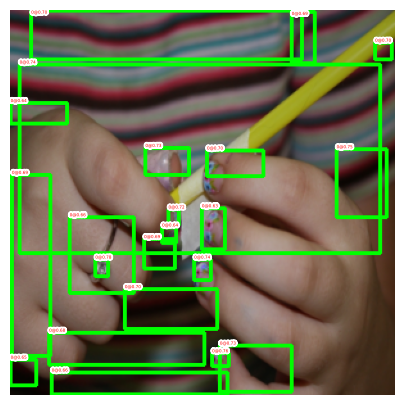

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


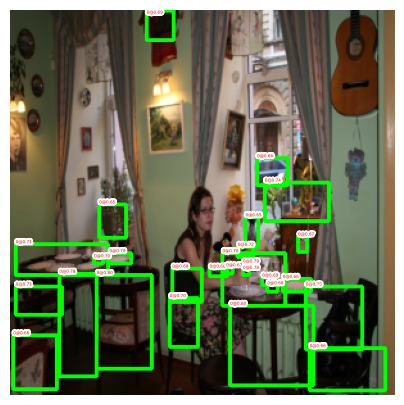

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


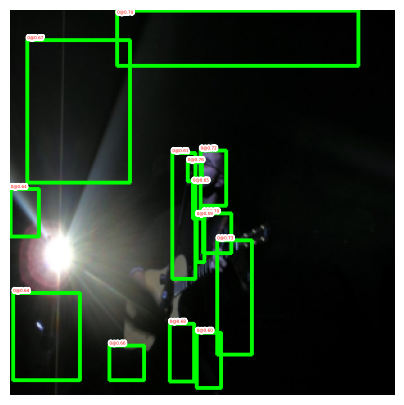

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


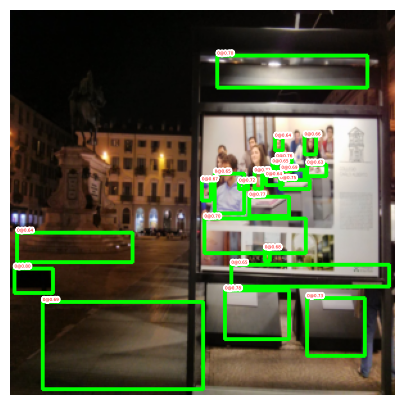

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


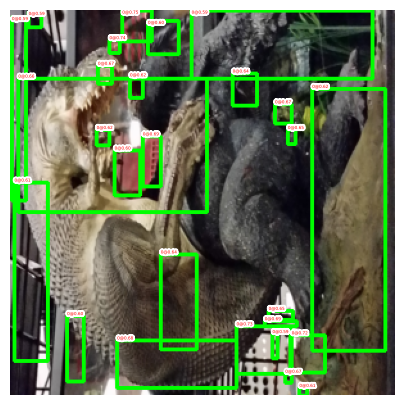

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


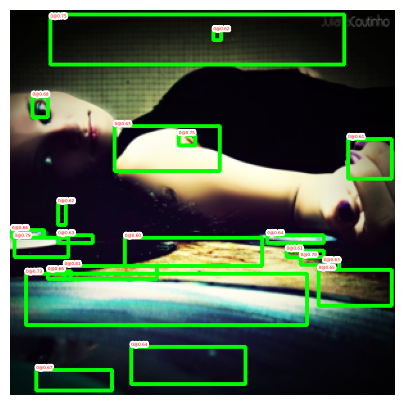

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


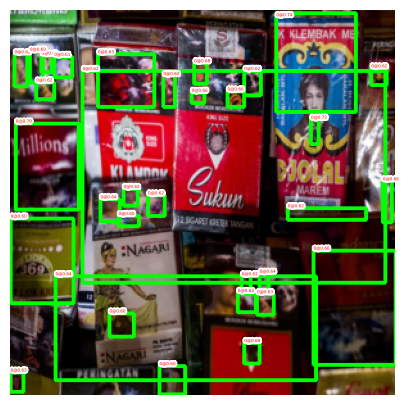

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


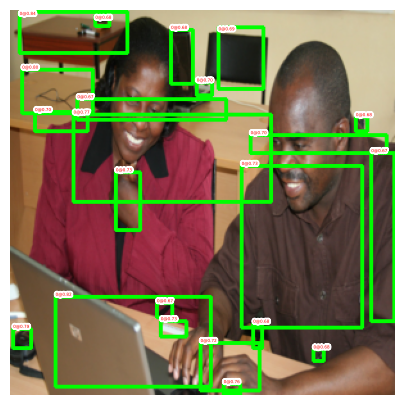

In [14]:
import numpy as np
import torch
from torch_snippets import show  # show() fonksiyonu için

model.eval()
with torch.no_grad():
    for batch_idx, (images, targets) in enumerate(val_loader):
        if batch_idx == 2:
            break

        # DataLoader’ın verdiği tuple → listeye dönüştürelim
        images_list = list(images)

        # İnferans
        outputs = model(images_list)

        # Her çıktı için görselleştirme
        for i, output in enumerate(outputs):
            bbs, confs, labels = decode_output(output)
            info = [f'{l}@{c:.2f}' for l, c in zip(labels, confs)]

            # Tensor [3,H,W] → CPU, HWC, 0..1 float. show() bunu kabul ediyor.
            img = images_list[i].cpu().permute(1,2,0)

            show(img, bbs=bbs, texts=info, sz=5)
